找到 59 个 shp 文件
图1已生成并保存到figure文件夹


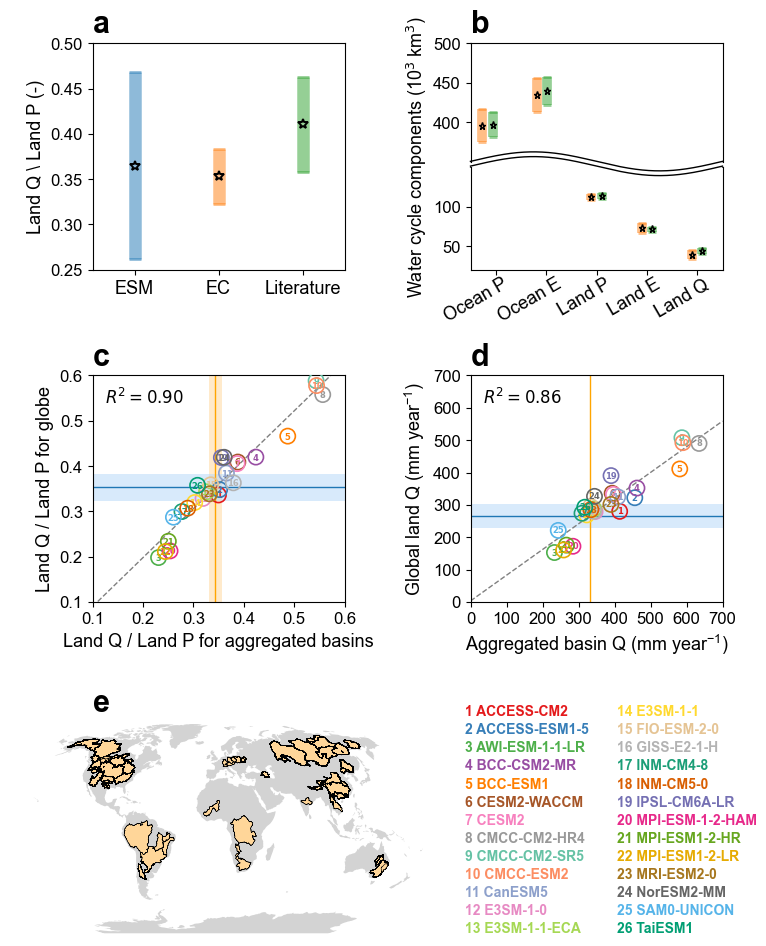

In [4]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from brokenaxes import brokenaxes
import numpy as np
from matplotlib.markers import MarkerStyle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from pathlib import Path
import random

fontfamily = 'Arial'

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x) * 50 + 50
y2 = np.concatenate([np.linspace(10, 120, 50), np.linspace(400, 500, 50)])

# 创建大图和GridSpec
fig = plt.figure(figsize=(7.5, 9.5))
plt.subplots_adjust(
    top=0.95,
    bottom=0.06,
    left=0.11,
    right=0.95,
    hspace=0.2,
    wspace=0.2
)
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8], hspace=0.5, wspace=0.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# ---- 子图1 ----
ax = fig.add_subplot(gs[0, 0])
Dm = [0.36491148200966, 0.352997910381556, 0.410389286122567]
Ds = [0.10328013711996, 0.0303390125361108, 0.0524461777041959]
# 数据
x = [1, 2, 3]
y = Dm
yerr = Ds
k = 0.2
# 绘制小花 marker
i = 0
for xi, yi, yerri in zip(x, y, yerr):
    marker_inner = dict(
        markersize=35 * k,
        markerfacecolor='None',
        markerfacecoloralt='lightsteelblue',
        markeredgecolor='k',
        markeredgewidth=7 * k,
    )

    # 内层星形 marker
    star_inner = MarkerStyle('*', fillstyle='full')
    star_inner._marker_transform = None
    ax.plot(xi, yi, marker=star_inner, **marker_inner, zorder=3)

    # 绘制误差棒
    ax.errorbar(
        xi, yi,
        yerr=yerri,
        fmt='',  # 不绘制默认 marker
        ecolor=colors[i],
        elinewidth=9,
        capsize=4,
        capthick=2,
        alpha=0.5,
        zorder=2,
    )
    i = i+1
ax.set_xlim([0.5, 3.5])
ax.set_ylim([0.25, 0.5])
plt.xticks([1, 2, 3], ["ESM", "EC", "Literature"], fontfamily=fontfamily, fontsize=13)
plt.yticks(fontfamily=fontfamily, fontsize=12)
plt.ylabel(r"Land Q \ Land P (-)", fontfamily=fontfamily, fontsize=13)

# ---- 子图2（断轴 + 波浪线 + 完整边框）----
bax = brokenaxes(
    ylims=((20, 150), (350, 500)),
    hspace=0.05,
    despine=False,
    subplot_spec=gs[0, 1],
    d=0.000001,       # 斜线长度，值越小越短
    # lw=1.0         # 斜线粗细
)
dm_ec = [395.55000000, 434.63000000, 112.43000000, 73.35000000, 39.08000000]
dm_literature = [396.675, 439.438333333333, 113.988333333333, 71.075, 43.7466666666667]
ds_ec = [20.60000000, 21.30000000, 4.20000000, 6.20000000, 5.40000000]
ds_literature = [15.61229483, 18.03021954, 3.73400812, 3.40290317, 3.27662428]

k = 0.1
x1 = [i-k for i in range(len(ds_ec))]
x2 = [i+k for i in range(len(ds_ec))]
k = 0.15
for xi1, yi1, yerri1, xi2, yi2, yerri2 in zip(x1, dm_ec, ds_ec, x2, dm_literature, ds_literature):
    marker_inner = dict(
        markersize=35 * k,
        markerfacecolor='None',
        markerfacecoloralt='lightsteelblue',
        markeredgecolor='k',
        markeredgewidth=7 * k,
    )

    # 内层星形 marker
    star_inner = MarkerStyle('*', fillstyle='full')
    star_inner._marker_transform = None
    bax.plot(xi1, yi1, marker=star_inner, **marker_inner, zorder=3)
    bax.plot(xi2, yi2, marker=star_inner, **marker_inner, zorder=3)

    # 绘制误差棒
    bax.errorbar(
        xi1, yi1,
        yerr=yerri1,
        fmt='',  # 不绘制默认 marker
        ecolor=colors[1],
        elinewidth=7,
        capsize=3,
        capthick=2,
        alpha=0.5,
        zorder=2,
    )
    bax.errorbar(
        xi2, yi2,
        yerr=yerri2,
        fmt='',  # 不绘制默认 marker
        ecolor=colors[2],
        elinewidth=7,
        capsize=3,
        capthick=2,
        alpha=0.5,
        zorder=2,
    )
# bax.set_title('Subplot 2 (broken axes)')

tickcolor = 'black'  # 黑色
ticklength = 6       # 刻度线长度
tickwidth = 1.0      # 刻度线粗细
labelpad = 0.5         # 标签距离轴距离

bax.axs[1].set_xlim([-0.5, 4.5])
# ax.set_ylim([0, 500])
bax.axs[1].set_xticks([0, 1, 2, 3, 4])
bax.axs[1].set_xticklabels([" ", " ", " ", " ", " "], rotation=30, ha='right')
# bax.axs[1].tick_params(axis='x',
#                       colors=tickcolor,
#                       labelsize=12,
#                       # length=ticklength,
#                       # width=tickwidth,
#                       pad=
xvals = [0.02, 0.235, 0.45, 0.65, 0.84]
labels = ["Ocean P", "Ocean E", "Land P", "Land E", "Land Q"]
y = -0.05  # 负值表示在轴下方偏移
for x, label in zip(xvals, labels):
    fig.text(x, y, label,
                   transform=bax.axs[1].transAxes,  # 坐标相对于轴 (0~1)
                   ha='center', va='top',
                   fontsize=13, fontname=fontfamily,
                   rotation=30)

bax.axs[1].set_yticks([50, 100])        # 下半部分
bax.axs[1].set_yticklabels(["50", "100"], fontsize=12, fontname=fontfamily)
bax.axs[0].set_yticks([400, 450, 500])  # 上半部分
bax.axs[0].set_yticklabels(["400", "450", "500"], fontsize=12, fontname=fontfamily)
# bax.set_xticklabels(["Ocean P", "Ocean E", "Land P", "Land E", "Q"],
#                     fontdict={'fontsize': 12, 'fontfamily': fontfamily, 'rotation': 30, 'ha': 'right'})
# plt.xticks([0, 1, 2, 3, 4], ["Ocean P", "Ocean E", "Land P", "Land E", "Q"], fontfamily=fontfamily, fontsize=14)
# plt.yticks([50, 100, 400, 450, 500], [50, 100, 400, 450, 500], fontfamily=fontfamily, fontsize=12)
plt.ylabel(r"Water cycle components (10$^3$ km$^3$)", fontfamily=fontfamily, fontsize=13, labelpad=30)

# 手动绘制波浪线
# 获取子图2在 Figure 中的位置
# 如果 axs 是 list
if isinstance(bax.axs, list):
    ax0 = bax.axs[0]
else:
    ax0 = bax.axs  # 已经是一个 Axes

pos = ax0.get_position()
x0, y0, w, h = pos.x0, pos.y0, pos.width, pos.height
import matplotlib.patches as mpatches
# 在整个figure上画一条波浪线
# 生成波浪线 (在 figure 坐标系里)
num_waves = 1   # 波浪数
wave_amp = 0.01  # 振幅（越大越高）
wave_len = w / num_waves

xs1 = np.linspace(x0, x0 + w, 500)
ys1 = y0 + h/2 + wave_amp * np.sin(2 * np.pi * (xs1 - x0) / wave_len) - 0.062

xs2 = np.linspace(x0, x0 + w, 500)
ys2 = y0 + h/2 + wave_amp * np.sin(2 * np.pi * (xs2 - x0) / wave_len) - 0.067

# 用 Line2D 在 figure 坐标里画
wave_line = plt.Line2D(xs1, ys1, transform=fig.transFigure,
                       color="black", lw=1.0)
fig.add_artist(wave_line)
wave_line = plt.Line2D(xs2, ys2, transform=fig.transFigure,
                       color="black", lw=1.0)
fig.add_artist(wave_line)

# 色盲友好配色
color_palette = [
    "#E69F00",  # 橙
    "#56B4E9",  # 天蓝
    "#009E73",  # 蓝绿色
    "#F0E442",  # 黄
    "#0072B2",  # 蓝
    "#CC79A7",  # 品红
]

# ---- 子图3 ----
ax3 = fig.add_subplot(gs[1, 0])
x = [
    0.349948, 0.352218, 0.231074, 0.424145, 0.487413, 0.388430, 0.386953, 0.556838,
    0.543665, 0.544552, 0.365752, 0.319330, 0.326260, 0.302807, 0.334676, 0.379448,
    0.277531, 0.288982, 0.355691, 0.253901, 0.250489, 0.244662, 0.332137, 0.361222,
    0.260558, 0.308476
]
y = [
    0.336123, 0.347955, 0.197934, 0.419747, 0.466016, 0.408794, 0.405253, 0.557738,
    0.588259, 0.577621, 0.384425, 0.328470, 0.343109, 0.319409, 0.358571, 0.362944,
    0.299529, 0.306950, 0.418659, 0.212623, 0.233906, 0.211178, 0.338709, 0.419323,
    0.287036, 0.357418
]
names = [
    "ACCESS-CM2", "ACCESS-ESM1-5", "AWI-ESM-1-1-LR", "BCC-CSM2-MR", "BCC-ESM1",
    "CESM2-WACCM", "CESM2", "CMCC-CM2-HR4", "CMCC-CM2-SR5", "CMCC-ESM2",
    "CanESM5", "E3SM-1-0", "E3SM-1-1-ECA", "E3SM-1-1", "FIO-ESM-2-0",
    "GISS-E2-1-H", "INM-CM4-8", "INM-CM5-0", "IPSL-CM6A-LR", "MPI-ESM-1-2-HAM",
    "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "MRI-ESM2-0", "NorESM2-MM", "SAM0-UNICON",
    "TaiESM1"
]

# 生成色带（colormap）
import matplotlib.cm as cm
# colors = cm.plasma(np.linspace(0, 1, len(x)))  # 可以换成 plt.cm.jet, plasma 等
colors = [
    "#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#A65628",
    "#F781BF", "#999999", "#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3",
    "#A6D854", "#FFD92F", "#E5C494", "#B3B3B3", "#1B9E77", "#D95F02",
    "#7570B3", "#E7298A", "#66A61E", "#E6AB02", "#A6761D", "#666666",
    "#56B4E9", "#009E73"
]
# cmap = plt.cm.tab20c  # 柔和有序，避免灰色和刺眼亮色
# colors = [cmap(i/25) for i in range(26)]

for i, (xi, yi) in enumerate(zip(x, y), start=1):
    # 画圆圈
    ax3.scatter(xi, yi, s=120, facecolors='none', edgecolors=colors[i-1], linewidth=1.2, zorder=10)
    # 在圆圈中心写序号
    ax3.text(xi, yi-0.001, str(i), color=colors[i-1],
            ha='center', va='center', fontsize=6, fontweight='bold', zorder=10)

from matplotlib.lines import Line2D
# 构造图例元素
# 图例文字
legend_labels = [f"{i+1} {name}" for i, name in enumerate(names)]
# 三列
ncols = 2
n_per_col = int(np.ceil(len(legend_labels) / ncols))  # 每列最多几个
row_space = 0.08
col_space = 0.6
x0 = 1.48  # 第一列起点
y0 = -1.92  # 顶部起点

for i, label in enumerate(legend_labels):
    col = i // n_per_col   # 列号
    row = i % n_per_col    # 行号（竖着走）
    ax.text(x0 + col*col_space, y0 - row*row_space, label,
            transform=ax.transAxes, fontsize=10, color=colors[i], fontfamily=fontfamily,
            weight='bold',
            va='top', ha='left'
            )


# 增加两条协调色，用于模型间不确定性
uncertainty_colors = [
    "#FFD699",  # 浅橙
    "#B3D7F9",  # 浅蓝
]
ax3.fill_betweenx([0.1, 0.6], 0.3439-0.0121, 0.3439+0.0121, color=uncertainty_colors[0], alpha=0.5, edgecolor='None')
ax3.plot([0.3439, 0.3439], [0.1, 0.6], color='orange', linewidth=1.0)

ax3.fill_between([0.1, 0.6], 0.353-0.0303, 0.353+0.0303, color=uncertainty_colors[1], alpha=0.5, edgecolor='None')
ax3.plot([0.1, 0.6], [0.353, 0.353], color='#1f77b4', linewidth=1.0)

# 线性拟合
coef = np.polyfit(x, y, 1)   # 1 表示一次多项式（直线）
x_fit = [0.1, 0.6]
y_fit = np.polyval(coef, x_fit)  # 计算拟合值

# 绘制拟合线
ax3.plot(x_fit, y_fit, '--', color='gray', linewidth=1)
plt.xlim([0.1, 0.6])
plt.ylim([0.1, 0.6])

r2 = 0.90
ax3.text(0.05, 0.95, f"$R^2={r2:.2f}$", transform=ax3.transAxes,
        fontsize=12, fontname='Arial', va='top', ha='left', color='black')

plt.xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], fontfamily=fontfamily, fontsize=12)
plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], fontfamily=fontfamily, fontsize=12)

plt.xlabel("Land Q / Land P for aggregated basins", fontfamily=fontfamily, fontsize=13)
plt.ylabel("Land Q / Land P for globe", fontfamily=fontfamily, fontsize=13)

# ---- 子图4 ----
ax4 = fig.add_subplot(gs[1, 1])
x = [
    414.3752877, 456.361136, 233.1467042, 462.3925914, 581.2934974,
    393.5436983, 397.3034825, 634.8266562, 587.2639748, 589.9865532,
    408.9352527, 346.0911368, 342.6181251, 323.0100624, 333.7297735,
    342.464713, 309.7145412, 334.3733438, 390.3327391, 284.5839434,
    266.4805571, 258.7142617, 390.0941628, 344.4088819, 243.7046931,
    317.4254284
]
y = [
    279.9205347, 322.0034787, 152.6342744, 351.9331247, 410.9781076,
    335.8289258, 332.227178, 489.7977781, 507.5621063, 492.2356203,
    324.7233414, 279.1472261, 287.374505, 268.9208894, 294.854358,
    280.2748223, 273.9657159, 285.1768978, 390.3885549, 172.0300834,
    175.5144917, 160.5464597, 301.2895597, 326.3084532, 221.058685,
    292.6842789
]
names = [
    "ACCESS-CM2", "ACCESS-ESM1-5", "AWI-ESM-1-1-LR", "BCC-CSM2-MR", "BCC-ESM1",
    "CESM2-WACCM", "CESM2", "CMCC-CM2-HR4", "CMCC-CM2-SR5", "CMCC-ESM2",
    "CanESM5", "E3SM-1-0", "E3SM-1-1-ECA", "E3SM-1-1", "FIO-ESM-2-0",
    "GISS-E2-1-H", "INM-CM4-8", "INM-CM5-0", "IPSL-CM6A-LR", "MPI-ESM-1-2-HAM",
    "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "MRI-ESM2-0", "NorESM2-MM", "SAM0-UNICON",
    "TaiESM1"
]

for i, (xi, yi) in enumerate(zip(x, y), start=1):
    # 画圆圈
    ax4.scatter(xi, yi, s=120, facecolors='none', edgecolors=colors[i-1], linewidth=1.2, zorder=10)
    # 在圆圈中心写序号
    ax4.text(xi, yi-0.1, str(i), color=colors[i-1],
            ha='center', va='center', fontsize=6, fontweight='bold', zorder=10)

# 增加两条协调色，用于模型间不确定性
uncertainty_colors = [
    "#FFD699",  # 浅橙
    "#B3D7F9",  # 浅蓝
]
# ax4.fill_betweenx([0, 700], 0.3439-0.0121, 0.3439+0.0121, color=uncertainty_colors[0], alpha=0.5, edgecolor='None')
ax4.plot([331.4204, 331.4204], [0, 700], color='orange', linewidth=1.0)

ax4.fill_between([0, 700], 266.2046-37.0628, 266.2046+37.0628, color=uncertainty_colors[1], alpha=0.5, edgecolor='None')
ax4.plot([0, 700], [266.2046, 266.2046], color='#1f77b4', linewidth=1.0)

# 线性拟合
coef = np.polyfit(x, y, 1)   # 1 表示一次多项式（直线）
x_fit = [0, 700]
y_fit = np.polyval(coef, x_fit)  # 计算拟合值

# 绘制拟合线
ax4.plot(x_fit, y_fit, '--', color='gray', linewidth=1)
plt.xlim([0, 700])
plt.ylim([0, 700])

r2 = 0.86
ax4.text(0.05, 0.95, f"$R^2={r2:.2f}$", transform=ax4.transAxes,
        fontsize=12, fontname='Arial', va='top', ha='left', color='black')

plt.xticks([0, 100, 200, 300, 400, 500, 600, 700], fontfamily=fontfamily, fontsize=12)
plt.yticks([0, 100, 200, 300, 400, 500, 600, 700], fontfamily=fontfamily, fontsize=12)

plt.xlabel(r"Aggregated basin Q (mm year$^{\mathregular{-1}}$)", fontfamily=fontfamily, fontsize=13)
plt.ylabel(r"Global land Q (mm year$^{\mathregular{-1}}$)", fontfamily=fontfamily, fontsize=13)

# fig.legend(
#     loc='center right',           # 图例中心在左侧
#     bbox_to_anchor=(0.99, 0.393),  # 相对于 figure 放置
#     borderaxespad=0,
#     handletextpad=0.5,          # 图标和文字的水平间距
#     labelspacing=0.2,           # 图例条目之间垂直间距（行距）
#     fontsize=10,
#     # title="Models"
# )

# ---- 子图5（单独一行，占两列）----
# ax5 = fig.add_subplot(gs[2, :], projection=ccrs.PlateCarree())
ax5 = fig.add_axes([0.00, 0.005, 0.55, 0.24], projection=ccrs.Robinson())  # 留出第三行位置
shp_root = Path("../data/shp")
shp_files = list(shp_root.rglob("*.shp"))
print(f"找到 {len(shp_files)} 个 shp 文件")
ax5.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
# # ax5.set_global()
# # ax5.coastlines(resolution='110m', linewidth=0.8)
# # ax5.add_feature(cfeature.BORDERS, linewidth=0.5)
ax5.add_feature(cfeature.LAND, facecolor='lightgray')   # 陆地灰色
# ax5.add_feature(cfeature.BORDERS, linewidth=0.5)
# ax5.add_feature(cfeature.LAND, facecolor='lightgray')
# ax5.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax5.axis("off")
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#CC79A7']
from cartopy.io.shapereader import Reader
for i, shp_file in enumerate(shp_files):
    try:
        shape_feature = cfeature.ShapelyFeature(
            Reader(str(shp_file)).geometries(),
            ccrs.PlateCarree(),
            edgecolor='k',
            # facecolor=colors[i % len(colors)],
            # linewidth=0.5,
            # alpha=0.6
            facecolor=uncertainty_colors[0],
            linewidth=0.35,
            alpha=1.0,
        )
        ax5.add_feature(shape_feature)
    except Exception as e:
        print(f"无法读取 {shp_file}: {e}")


# 图序号
labels = ['a', 'b', 'c', 'd', 'e']

# 通过 fig.text 添加序号
# x, y 坐标是相对于整个 figure（0~1）
# ha='left', va='top' 调整对齐
positions = [
    (0.11, 0.955),  # 子图1 左上角
    (0.615, 0.955),  # 子图2
    (0.11, 0.605),   # 子图3
    (0.615, 0.605),   # 子图4
    (0.11, 0.24)    # 子图5（占一整行）
]

for label, (x, y) in zip(labels, positions):
    fig.text(x, y, label, fontsize=22, fontweight='bold', va='bottom', ha='left', fontfamily=fontfamily)

fig.patch.set_alpha(1.0)
# plt.tight_layout()

plt.rcParams['savefig.dpi'] = 2000
# 保存图形
plt.savefig('../figure/fig1.png', dpi=600, bbox_inches='tight')

print("图1已生成并保存到figure文件夹")
plt.show()
